/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


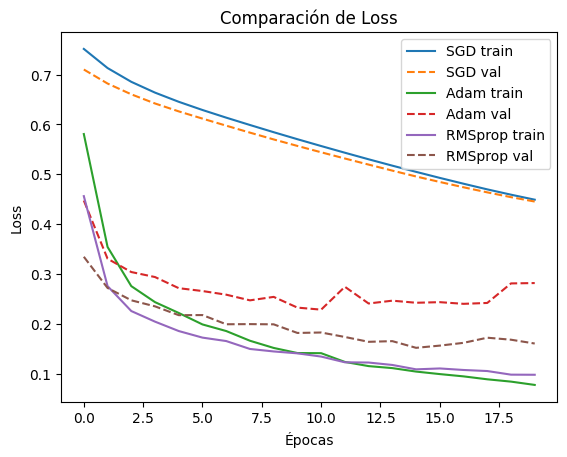

SGD - Accuracy final: 0.8450
Adam - Accuracy final: 0.9300
RMSprop - Accuracy final: 0.9300


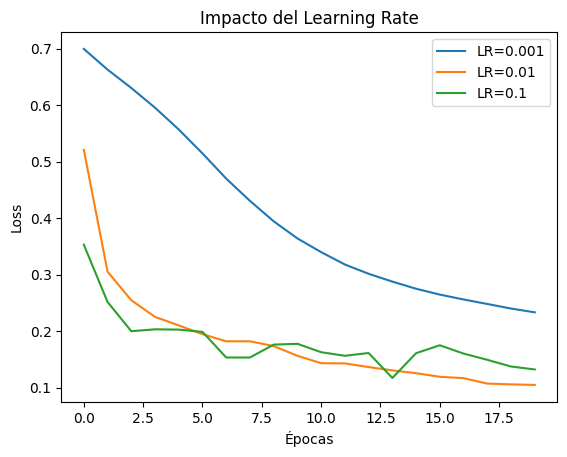

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Preparar datos
X, y = make_classification(n_samples=1000, n_features=10, 
                           n_informative=5, n_redundant=2,
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Definir modelos
def crear_modelo():
    model = Sequential([
        Dense(16, activation='relu', input_shape=(10,)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

#Entrenar optimizadores
optimizadores = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.01),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.01)
}

historiales = {}

for nombre, opt in optimizadores.items():
    model = crear_modelo()
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=20,
                        batch_size=32,
                        verbose=0)
    
    historiales[nombre] = history

#Gráfica de loss
plt.figure()

for nombre, history in historiales.items():
    plt.plot(history.history['loss'], label=f'{nombre} train')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'{nombre} val')

plt.title("Comparación de Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Comparación accuracy final
for nombre, history in historiales.items():
    acc = history.history['val_accuracy'][-1]
    print(f"{nombre} - Accuracy final: {acc:.4f}")

#Learning rate
learning_rates = [0.001, 0.01, 0.1]
resultados_lr = {}

for lr in learning_rates:
    model = crear_modelo()
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=20,
                        verbose=0)
    
    resultados_lr[lr] = history

#Gráfica learning rate
plt.figure()

for lr, history in resultados_lr.items():
    plt.plot(history.history['loss'], label=f'LR={lr}')

plt.title("Impacto del Learning Rate")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()